In [1]:
#### Energy Demand Forecasting ####

In [2]:
#Objective: A utility company wanted to predict the electricity demand accurately to optimize power generation and distribution.

In [3]:
# Approach: Time series data from past years, including historical demand, weather data, and holidays was collected. SARIMA and Prophet models were used to capture seasonality and trends. DeepAR was applied for probabilistic forecasting with prediction intervals.

In [4]:
#Outcome: The accurate forecasts enabled the utility company to optimize power generation, reduce operational costs, and prevent energy shortages during peak demand periods.

In [5]:
import pandas as pd

#load the dataset
data=pd.read_csv('TimeSeries_TotalSolarGen_and_Load_IT_2016.csv')
data.head()

,utc_timestamp,IT_load_new,IT_solar_generation
0,2016-01-01T00:00:00Z,21665.0,1
1,2016-01-01T01:00:00Z,20260.0,0
2,2016-01-01T02:00:00Z,19056.0,0
3,2016-01-01T03:00:00Z,18407.0,0
4,2016-01-01T04:00:00Z,18425.0,0


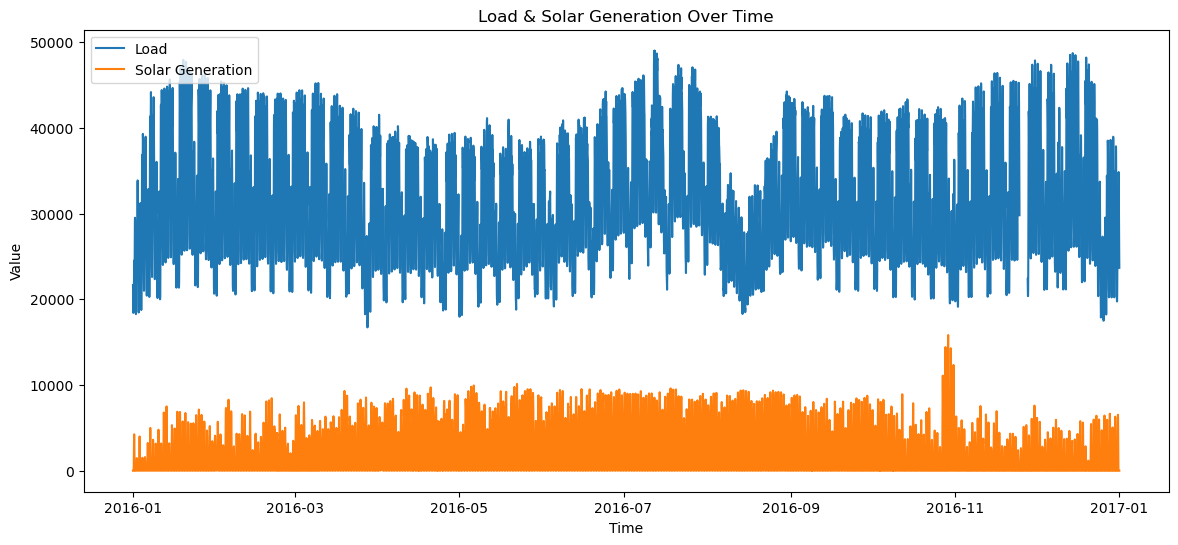

In [10]:
#visualize the data
import matplotlib.pyplot as plt

#convert utc_timestamp to datetime
data['utc_timestamp']=pd.to_datetime(data['utc_timestamp'])

#plot the data
plt.figure(figsize=(14,6))

plt.plot(data['utc_timestamp'],data['IT_load_new'],label='Load')
plt.plot(data['utc_timestamp'],data['IT_solar_generation'],label='Solar Generation')
plt.xlabel('Time')
plt.ylabel('Value')
plt.title('Load & Solar Generation Over Time')
plt.legend()
plt.show()

#The plot shows both the load and solar generation over time for the year 2016. The load appears to have a cyclical pattern with peaks and valleys, possibly corresponding to daily patterns of electricity use.
#The solar generation also shows a clear pattern, with generation during the day and no generation at night (as expected). The amount of solar generation also appears to fluctuate throughout the year, likely due to seasonal changes in sunlight.
#Before moving on to time series analysis and forecasting with ARIMA, it's important to check for stationarity in your time series data. Stationarity is a property of time series data that implies the mean, variance, and autocorrelation structure do not change over time. Many time series models, including ARIMA, require the data to be stationary.
#Let's perform an Augmented Dickey-Fuller test to check the stationarity of the time series. The null hypothesis of the ADF test is that the time series is non-stationary. So, if the p-value of the test is less than the significance level (0.05) then you reject the null hypothesis and infer that the time series is indeed stationary.

In [11]:
#check for missing values
data.isnull().sum()

utc_timestamp           0
IT_load_new            72
IT_solar_generation     0
dtype: int64

In [13]:
#fill missing values using forward fill
data['IT_load_new'].fillna(method='ffill',inplace=True)

#check for missing values again
print('Missing Values after filling')
print(data.isnull().sum())

Missing Values after filling
utc_timestamp          0
IT_load_new            0
IT_solar_generation    0
dtype: int64


C:\Users\pande\AppData\Local\Temp\ipykernel_16812\2381516211.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['IT_load_new'].fillna(method='ffill',inplace=True)
C:\Users\pande\AppData\Local\Temp\ipykernel_16812\2381516211.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data['IT_load_new'].fillna(method='ffill',inplace=True)


In [17]:
#Check for stationarity: whether the data is stationary or not
from statsmodels.tsa.stattools import adfuller

# Function to perform Augmented Dickey-Fuller test
def adf_test(timeseries):
    print('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    for key,value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
    print (dfoutput)

In [18]:
#Perform Augmented Dickey-Fuller test again
print("\nADF test for 'IT_load_new' after filling missing values:")
adf_test(data['IT_load_new'])

print("\nADF test for 'IT_solar_generation':")
adf_test(data['IT_solar_generation'])

#The data is already stationary since the p-value is extremely low


ADF test for 'IT_load_new' after filling missing values:
Results of Dickey-Fuller Test:
Test Statistic                -1.197390e+01
p-value                        3.841445e-22
#Lags Used                     3.700000e+01
Number of Observations Used    8.746000e+03
Critical Value (1%)           -3.431098e+00
Critical Value (5%)           -2.861871e+00
Critical Value (10%)          -2.566946e+00
dtype: float64

ADF test for 'IT_solar_generation':
Results of Dickey-Fuller Test:
Test Statistic                -5.741335e+00
p-value                        6.265438e-07
#Lags Used                     3.600000e+01
Number of Observations Used    8.747000e+03
Critical Value (1%)           -3.431098e+00
Critical Value (5%)           -2.861870e+00
Critical Value (10%)          -2.566946e+00
dtype: float64


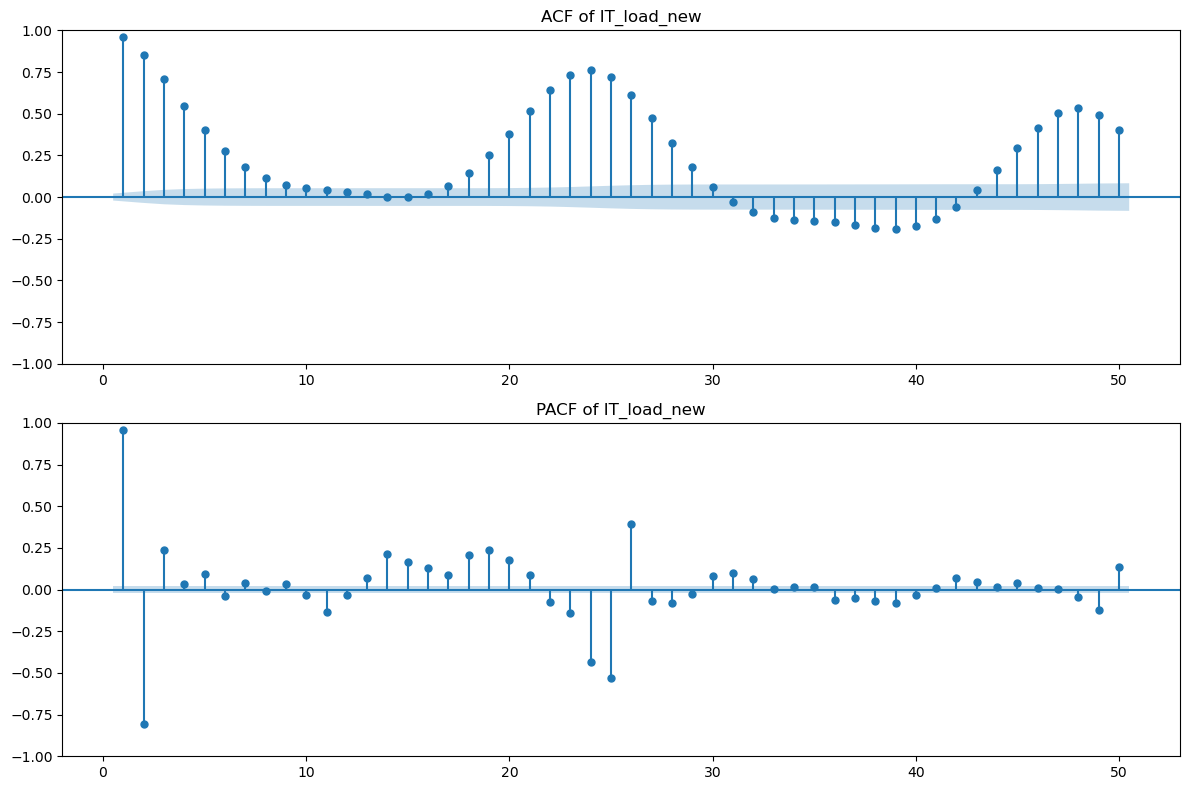

In [21]:
#Build ARIMA Model for 'IT_load_new'
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Plot ACF and PACF
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

plot_acf(data['IT_load_new'], lags=50, zero=False, ax=ax1)
ax1.set_title('ACF of IT_load_new')

plot_pacf(data['IT_load_new'], lags=50, zero=False, ax=ax2)
ax2.set_title('PACF of IT_load_new')

plt.tight_layout()
plt.show()

#From the ACF plot, we observe a gradual decline in the autocorrelations, while the PACF plot shows a sharp drop after lag 2. Based on this pattern, we choose p = 2 and q = 2 as the parameters for our ARIMA model.
#Next, we fit the ARIMA model to the IT_load_new time series. For model estimation and evaluation, the dataset is divided into two parts: the first 80% of the observations are used as the training set, and the remaining 20% are used as the testing set. This split allows us to train the model on historical data and then assess its forecasting performance on unseen data, providing a more reliable evaluation of the model’s accuracy.

In [32]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
from math import sqrt

# Split the data into training and test sets
train_size = int(len(data['IT_load_new']) * 0.8)
train, test = data['IT_load_new'][:train_size], data['IT_load_new'][train_size:]

# Fit the ARIMA model
model = ARIMA(train, order=(2,0,2))
model_fit = model.fit()

# Make predictions on the test set
predictions = model_fit.predict(start=len(train), end=len(train)+len(test)-1)

# Calculate RMSE
rmse = sqrt(mean_squared_error(test, predictions))
rmse

7714.95213484407

In [31]:
# Split the data into training and test sets
train_size = int(len(data['IT_load_new']) * 0.8)
train, test = data['IT_load_new'][:train_size], data['IT_load_new'][train_size:]

# Fit the ARIMA model
model2 = ARIMA(train, order=(2,1,2))
model_fit2 = model2.fit()

# Make predictions on the test set
predictions2 = model_fit2.predict(start=len(train), end=len(train)+len(test)-1)

# Calculate RMSE
rmse2 = sqrt(mean_squared_error(test, predictions2))
rmse2

7993.849409027767

In [24]:
# Split the data into training and test sets
train_size = int(len(data['IT_load_new']) * 0.8)
train, test = data['IT_load_new'][:train_size], data['IT_load_new'][train_size:]

# Fit the ARIMA model
model3 = ARIMA(train, order=(2,2,2))
model_fit3 = model3.fit()

# Make predictions on the test set
predictions3 = model_fit3.predict(start=len(train), end=len(train)+len(test)-1)

# Calculate RMSE
rmse3 = sqrt(mean_squared_error(test, predictions3))
rmse3

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


9268.991590567692

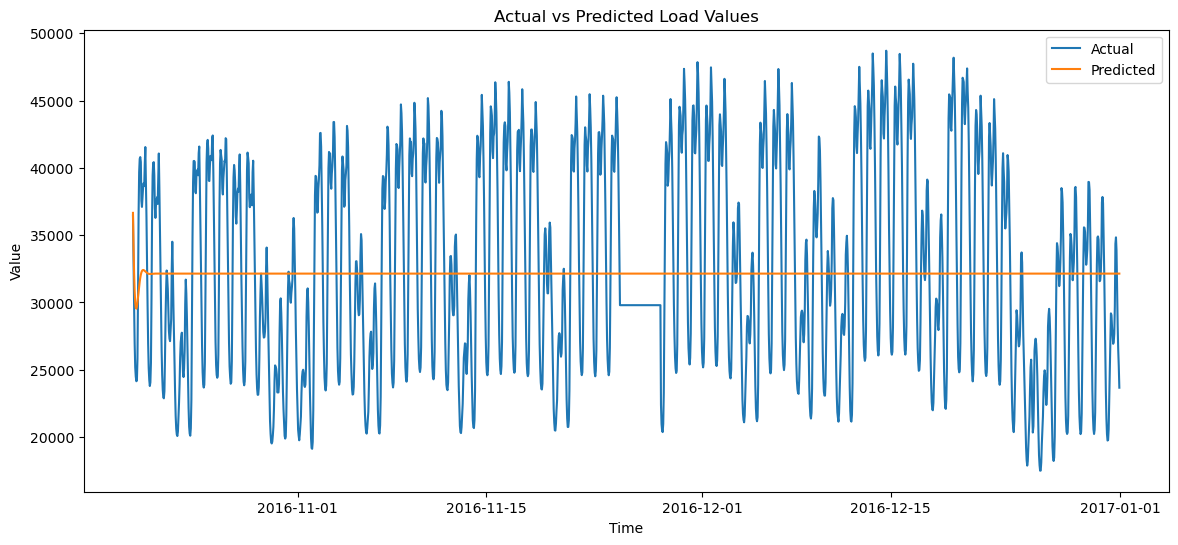

In [34]:
#plot actual vs predicted values
plt.figure(figsize=(14,6))
plt.plot(data['utc_timestamp'][train_size:], test, label='Actual')
plt.plot(data['utc_timestamp'][train_size:], predictions, label='Predicted')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.title('Actual vs Predicted Load Values')
plt.show()

#The plot compares the actual and predicted load values for the test dataset. The ARIMA model appears to capture the overall pattern and structure of the time series reasonably well. However, there are still some differences between the actual and predicted values. These discrepancies may arise due to factors such as the inherent randomness present in the data, the influence of variables that are not included in the model, or the limitations of the ARIMA model itself. Using more advanced models or performing additional data preprocessing could potentially improve the forecasting performance.
#Next, we repeat the same procedure for the IT solar generation time series. The process begins by plotting the ACF and PACF graphs to identify the appropriate parameters for the ARIMA model.

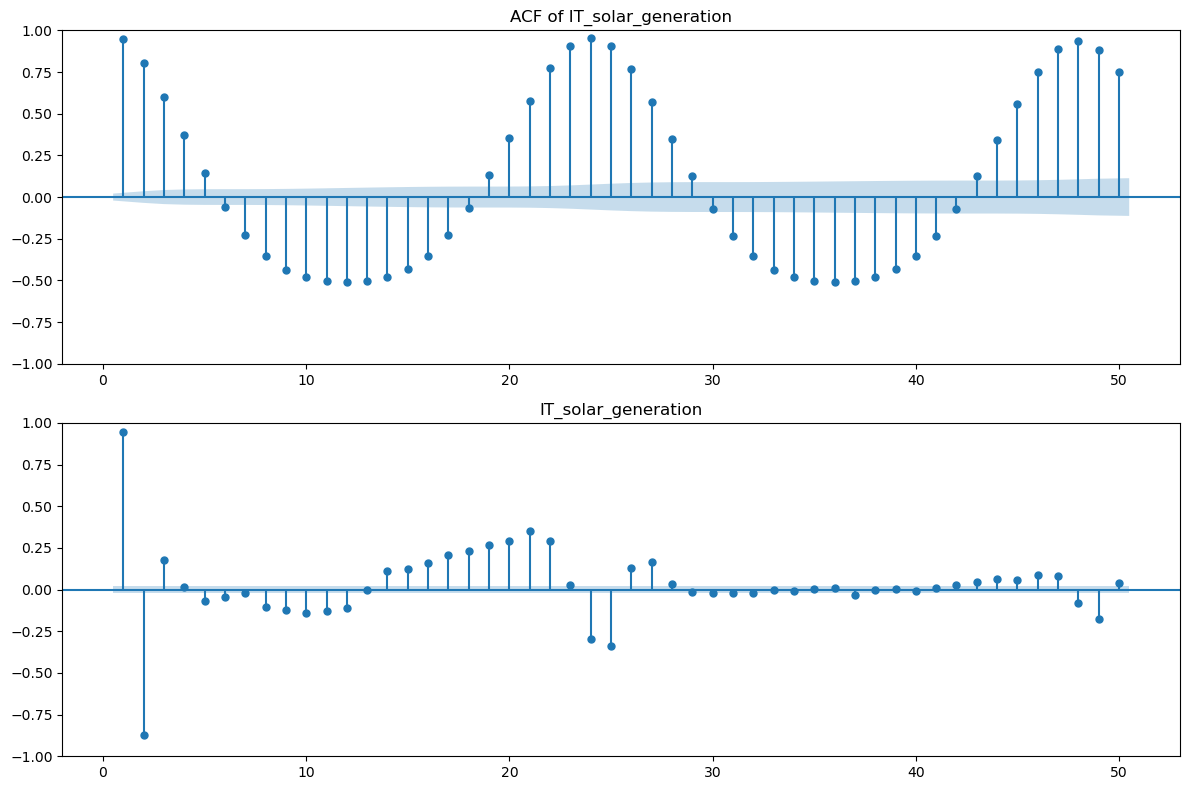

In [35]:
# Plot ACF and PACF for IT_solar_generation
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

plot_acf(data['IT_solar_generation'], lags=50, zero=False, ax=ax1)
ax1.set_title('ACF of IT_solar_generation')

plot_pacf(data['IT_solar_generation'], lags=50, zero=False, ax=ax2)
ax2.set_title('IT_solar_generation')

plt.tight_layout()
plt.show()

In [36]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
from math import sqrt

# Split the data into training and test sets
train_size = int(len(data['IT_solar_generation']) * 0.8)
train, test = data['IT_solar_generation'][:train_size], data['IT_solar_generation'][train_size:]

# Fit the ARIMA model
model = ARIMA(train, order=(2,0,2))
model_fit = model.fit()

# Make predictions on the test set
predictions = model_fit.predict(start=len(train), end=len(train)+len(test)-1)

# Calculate RMSE
rmse = sqrt(mean_squared_error(test, predictions))
rmse

2486.150711091106

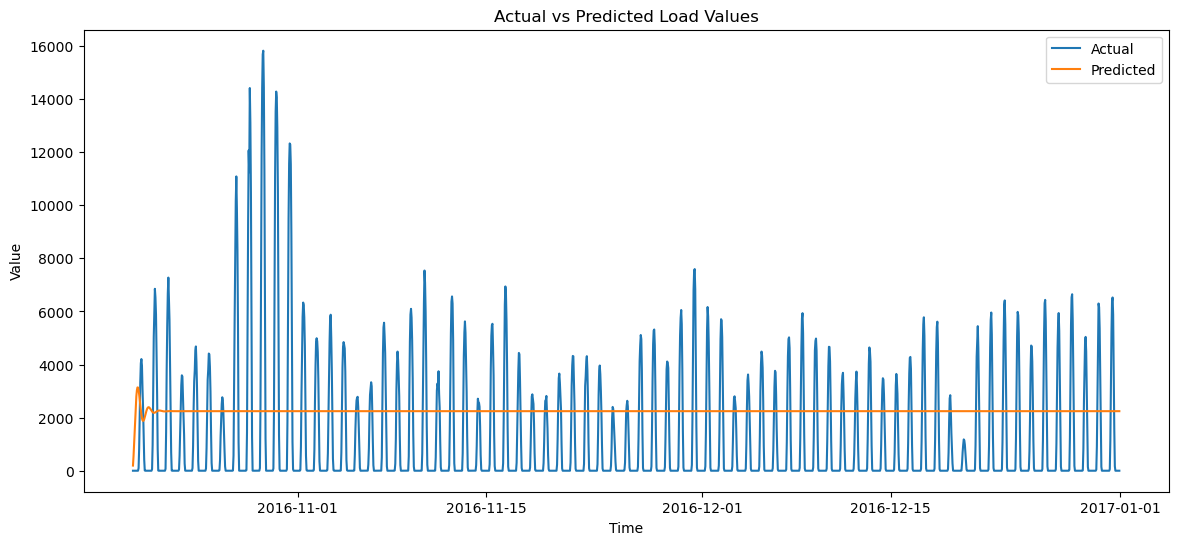

In [38]:
#plot actual vs predicted values
plt.figure(figsize=(14,6))
plt.plot(data['utc_timestamp'][train_size:], test, label='Actual')
plt.plot(data['utc_timestamp'][train_size:], predictions, label='Predicted')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.title('Actual vs Predicted Load Values')
plt.show()

#The plot shows the 'actual versus predicted solar generation values for the test dataset'. Similar to the load model, the ARIMA model captures the general pattern of the time series data, although some differences between the actual and predicted values may still be observed.

In [39]:
### Conclusion
#In this project, time series analysis was conducted on **IT Load** and **IT Solar Generation** using the **ARIMA model**. After preprocessing the data and ensuring stationarity, ACF and PACF plots were used to determine suitable model parameters. The dataset was divided into 80% training data and 20% testing data to evaluate the model’s performance on unseen observations.
#The results show that the **ARIMA model captures the overall trend and structure of both time series reasonably well, as the predicted values follow the general pattern of the actual data. Although some deviations remain due to randomness in the data and possible external influences not included in the model, the forecasts still provide useful insights.
#Overall, this project demonstrates how **ARIMA can be effectively applied for time series forecasting of energy-related data**, while also highlighting that more advanced models or additional preprocessing could further improve prediction accuracy.